# Header

In [1]:
import importlib
import xarray_sf_funcs as xsfuncs
from dask.distributed import Client
import dask
import os
import re
import glob
import warnings
import logging

# Reload the xsfuncs module
importlib.reload(xsfuncs)

warnings.filterwarnings("ignore")


In [2]:
region_dict = {
    'acc': {'lat_north': -53, 'lat_south': -57.5, 'lon_east': 158, 'lon_west': 148, 'reduce_xd_num': 1},
    'nwpacific': {'lat_north': 23, 'lat_south': 19, 'lon_east': 137, 'lon_west': 132, 'reduce_xd_num': 1},
    'capebasin': {'lat_north': -41.01421, 'lat_south': -44.99279, 'lon_east': 16, 'lon_west': 11, 'reduce_xd_num': 1},
    'newcaledonia': {'lat_north': -22, 'lat_south': -26, 'lon_east': 171, 'lon_west': 166, 'reduce_xd_num': 1},
    'nwaustralia': {'lat_north': -11, 'lat_south': -15, 'lon_east': 125, 'lon_west': 120, 'reduce_xd_num': 1},
    'westatlantic': {'lat_north': 38.7, 'lat_south': 32.7, 'lon_east': -73, 'lon_west': -76, 'reduce_xd_num': 1},
    'labradorsea': {'lat_north': 63.79824, 'lat_south': 59.5549, 'lon_east': -58.52856, 'lon_west': -63.61784, 'reduce_xd_num': 1},
    # 'Florida': {'lat_north': 29, 'lat_south': 24, 'lon_east': -77, 'lon_west': -82, 'reduce_xd_num': 1},
    # 'GrandBanks': {'lat_north': 40, 'lat_south': 35, 'lon_east': -45, 'lon_west': -50, 'reduce_xd_num': 1},
    # 'Arbic': {'lat_north': 43, 'lat_south': 27.5, 'lon_east': -40, 'lon_west': -60, 'reduce_xd_num': 1},
    # 'Equator': {'lat_north': 5, 'lat_south': -5, 'lon_east': -10, 'lon_west': -35, 'reduce_xd_num': 1},
    # 'Interior': {'lat_north': 32, 'lat_south': 22, 'lon_east': -30, 'lon_west': -42, 'reduce_xd_num': 1},
    # 'GulfStream': {'southwest': (-80, 25), 'southeast': (-35, 25), 'northwest': (-80, 39), 'northeast': (-35, 49), 'reduce_xd_num': 1}
}

# simSWOT

In [ ]:
import gc
import os
import re
import glob
import time
import signal
import warnings
import logging

# Configure Dask memory settings
dask.config.set({
    "distributed.worker.memory.target": 0.7,
    "distributed.worker.memory.spill": 0.8,
    "distributed.worker.memory.pause": 0.85,
    "distributed.worker.memory.terminate": 0.95,
    "logging.distributed": "error",
})

def create_client():
    """Helper function to create a new Dask client."""
    return Client(
        n_workers=16,
        threads_per_worker=1,
        memory_limit="22GB",
        silence_logs=logging.WARNING,
    )

def reset_client(client):
    """Safely reset Dask client without crashing on teardown timeouts."""
    try:
        client.shutdown()
    except Exception as shutdown_err:
        print(f"Client shutdown warning (safe to ignore): {shutdown_err}")

    try:
        client.close()
    except Exception as close_err:
        print(f"Client close warning (safe to ignore): {close_err}")

    gc.collect()
    new_client = create_client()
    print("Created a fresh Dask client")
    return new_client

class RunTimeoutError(TimeoutError):
    pass

def _timeout_handler(signum, frame):
    raise RunTimeoutError("Run exceeded timeout window without completion")

# macOS supports SIGALRM (this notebook appears to run on macOS)
signal.signal(signal.SIGALRM, _timeout_handler)

# ---------- Tunables ----------
STALL_TIMEOUT_MIN = 20          # hard timeout per region/cycle attempt
STALL_TIMEOUT_SEC = STALL_TIMEOUT_MIN * 60
MAX_RETRIES = 2                 # retries per region/cycle before skip
run_new = False                 # False => skip existing completed outputs
# -----------------------------

USE_TRY_EXCEPT = True
client = create_client()

region_skips = [
    # "acc", "already processed",
    # "nwpacific", "already processed",
    # "capebasin", "already processed",
    # "labradorsea", "already processed",
    # "nwaustralia", "already processed",
    # "westatlantic", "already processed",
    # "newcaledonia", "already processed",
]

SIMSWOT_PHASE = "fast_phase" # options: "fast_phase", "science_phase"

problematic_region_cycles = []
problematic_log_path = "problematic_region_cycles.log"

parent_dir = f"/Volumes/Promise Disk/data/simulated_swot/{SIMSWOT_PHASE}"
glob_pattern = f"{parent_dir}/*.nc"
output_dir = f"data/simSWOT/{SIMSWOT_PHASE}/2026-04-19"


file_names = glob.glob(glob_pattern)
file_names = [os.path.basename(fn) for fn in file_names]
cycle_nums = sorted(set(
    re.search(r"Expert_(\d+)", fn).group(1).zfill(3)
    for fn in file_names if re.search(r"Expert_(\d+)", fn)
))
print(f"Found cycle numbers: {cycle_nums}")
print(f"run_new={run_new} (False means completed outputs will be skipped)")

ASF = True
LLL = True
CG = True
scalar = None
Bessels = True
timemean_removal_method = None # options: None, "cycle_mean", "linear_fit"
cleaned = False
taper_SF = True
flip_swath = True
suffix = ""

suffix += f"timemean_removed_{timemean_removal_method}" if timemean_removal_method else ""
suffix += "_cleaned" if cleaned else ""
suffix += "_flipped_swath" if flip_swath else ""
suffix += f"{scalar}" if scalar else ""
suffix += "_LLL" if LLL else ""
suffix += "_Bessels" if Bessels else ""
suffix += "_tapered" if taper_SF else ""
suffix += "_CG" if CG else ""
print(f"Output filename suffix: {suffix}")

for idx, cycnum in enumerate(cycle_nums):
    print(f"\nProcessing cycle: {cycnum}")

    # periodic proactive reset
    if idx > 0 and idx % 10 == 0:
        print(f"Restarting Dask client after {idx} iterations...")
        client = reset_client(client)

    print(f"Dask dashboard link: {client.dashboard_link}")

    for region, params in region_dict.items():
        if region in region_skips:
            print(f"Skipping region: {region}, {region_skips[region_skips.index(region) + 1]}")
            continue

        reduce_xd_num = params["reduce_xd_num"]
        lat_north = params["lat_north"]
        lat_south = params["lat_south"]
        lon_east = params["lon_east"]
        lon_west = params["lon_west"]

        # convert negative longitudes to 0..360
        if lon_west < 0:
            lon_west += 360
        if lon_east < 0:
            lon_east += 360

        print(f"Processing region: {region} with reduce_xd_num: {reduce_xd_num}")

        region_output_dir = os.path.join(output_dir, region)
        os.makedirs(region_output_dir, exist_ok=True)

        def matching_outputs():
            return [
                f for f in os.listdir(region_output_dir)
                if (
                    f.endswith(".nc")
                    and suffix in f
                    and f"simSWOT_{region}_cycle_{cycnum}" in f
                )
            ]

        # skip completed
        if not run_new:
            existing_files = matching_outputs()
            if existing_files:
                print(f"Skipping cycle {cycnum} for region {region} as output file already exists: {existing_files[0]}")
                continue

        def run_once():
            print(f"Processing cycle {cycnum} for region {region}")
            before_files = set(matching_outputs())

            signal.alarm(STALL_TIMEOUT_SEC)
            try:
                with warnings.catch_warnings(record=True) as caught_warnings:
                    warnings.simplefilter("always")
                    xsfuncs.compute_and_save_simswot(
                        filepath=glob_pattern,
                        outpath=output_dir,
                        region_name=region,
                        cycle_num=cycnum,
                        lat_north=lat_north,
                        lat_south=lat_south,
                        lon_east=lon_east,
                        lon_west=lon_west,
                        ASF=ASF,
                        LLL=LLL,
                        CG=CG,
                        cleaned=False,
                        reduce_xd_num=reduce_xd_num,
                        scalar=scalar,
                        Bessels=Bessels,
                        timemean_removal_method=timemean_removal_method,
                        taper_SF=taper_SF,
                        flip_swath=flip_swath,
                    )

                    # Optional: escalate memory warning strings if emitted as warnings
                    for w in caught_warnings:
                        if "Unmanaged memory use is high" in str(w.message):
                            raise RuntimeError("Unmanaged memory warning")

            finally:
                signal.alarm(0)

            client.run(gc.collect)

            after_files = set(matching_outputs())
            if len(after_files - before_files) == 0 and len(after_files) == 0:
                raise RuntimeError("No matching output file detected after computation")

        retries = 0
        while retries < MAX_RETRIES:
            try:
                print(f"Attempt {retries + 1}/{MAX_RETRIES} for cycle {cycnum}, region {region}")
                run_once()
                break

            except RunTimeoutError as e:
                retries += 1
                print(f"Timeout for region {region}, cycle {cycnum}: {e}")
                client = reset_client(client)
                gc.collect()

                if retries >= MAX_RETRIES:
                    reason = f"timeout after {MAX_RETRIES} retries"
                    print(f"Skipping cycle {cycnum} for region {region}: {reason}")
                    problematic_region_cycles.append((cycnum, region, reason))
                    with open(problematic_log_path, "a") as log_file:
                        log_file.write(f"cycle={cycnum}, region={region}, reason={reason}\n")

            except RuntimeError as e:
                retries += 1
                print(f"RuntimeError for region {region}, cycle {cycnum}: {e}")
                client = reset_client(client)
                gc.collect()

                if retries >= MAX_RETRIES:
                    reason = f"runtime: {e}"
                    print(f"Skipping cycle {cycnum} for region {region}: {reason}")
                    problematic_region_cycles.append((cycnum, region, reason))
                    with open(problematic_log_path, "a") as log_file:
                        log_file.write(f"cycle={cycnum}, region={region}, reason={reason}\n")
                else:
                    print(f"Retrying cycle {cycnum} for region {region}...")

            except SyntaxError as e:
                retries += 1
                print(f"SyntaxError for region {region}, cycle {cycnum}: {e}")
                # print traceback for debugging
                import traceback
                traceback.print_exc()
                client = reset_client(client)
                gc.collect()

                if retries >= MAX_RETRIES:
                    reason = f"exception: {e}"
                    print(f"Skipping cycle {cycnum} for region {region}: {reason}")
                    problematic_region_cycles.append((cycnum, region, reason))
                    with open(problematic_log_path, "a") as log_file:
                        log_file.write(f"cycle={cycnum}, region={region}, reason={reason}\n")
                else:
                    print(f"Retrying cycle {cycnum} for region {region}...")

print("\nRun complete.")
if problematic_region_cycles:
    print("Problematic cycle/region pairs:")
    for cyc, reg, reason in problematic_region_cycles:
        print(f"  - cycle {cyc}, region {reg}: {reason}")
    print(f"Logged problematic pairs to {problematic_log_path}")
else:
    print("No problematic cycle/region pairs recorded.")

# Final cleanup
try:
    client.shutdown()
except Exception as e:
    print(f"Final client shutdown warning (safe to ignore): {e}")

try:
    client.close()
except Exception as e:
    print(f"Final client close warning (safe to ignore): {e}")

Found cycle numbers: ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025', '026', '027', '028', '029', '030', '031', '032', '033', '034', '035', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '046', '047', '048', '049', '050', '051', '052', '053', '054', '055', '056', '057', '058', '059', '060', '061', '062', '063', '064', '065', '066', '067', '068', '069', '070', '071', '072', '073', '074', '075', '076', '077', '078', '079', '080', '081', '082', '083', '084', '085', '086', '087', '088', '089', '090', '091', '092', '093', '094', '095', '096', '097', '098', '099', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140'

# simSWOT fast phase

In [ ]:
import gc
import os
import re
import glob
import time
import signal
import warnings
import logging
import xarray as xr

# Configure Dask memory settings
dask.config.set({
    "distributed.worker.memory.target": 0.7,
    "distributed.worker.memory.spill": 0.8,
    "distributed.worker.memory.pause": 0.85,
    "distributed.worker.memory.terminate": 0.95,
    "logging.distributed": "error",
})

def create_client():
    """Helper function to create a new Dask client."""
    return Client(
        n_workers=8,
        threads_per_worker=1,
        memory_limit="40GB",
        silence_logs=logging.WARNING,
    )

def reset_client(client):
    """Safely reset Dask client without crashing on teardown timeouts."""
    try:
        client.shutdown()
    except Exception as shutdown_err:
        print(f"Client shutdown warning (safe to ignore): {shutdown_err}")

    try:
        client.close()
    except Exception as close_err:
        print(f"Client close warning (safe to ignore): {close_err}")

    gc.collect()
    new_client = create_client()
    print("Created a fresh Dask client")
    return new_client

class RunTimeoutError(TimeoutError):
    pass

def _timeout_handler(signum, frame):
    raise RunTimeoutError("Run exceeded timeout window without completion")

# macOS supports SIGALRM (this notebook appears to run on macOS)
signal.signal(signal.SIGALRM, _timeout_handler)

# ---------- Tunables ----------
STALL_TIMEOUT_MIN = 20          # hard timeout per region/cycle attempt
STALL_TIMEOUT_SEC = STALL_TIMEOUT_MIN * 60
MAX_RETRIES = 2                 # retries per region/cycle before skip
run_new = False                 # False => skip existing completed outputs
# -----------------------------

USE_TRY_EXCEPT = True
client = create_client()

region_skips = [
    # "acc", "already processed",
    # "nwpacific", "already processed",
    # "capebasin", "already processed",
    "labradorsea", "too large, redo with fewer cycles",
    # "nwaustralia", "already processed",
    "westatlantic", "too large, redo with fewer cycles",
    # "newcaledonia", "already processed",
]

SIMSWOT_PHASE = "fast_phase" # options: "fast_phase", "science_phase"

problematic_region_cycles = []
problematic_log_path = "problematic_region_cycles.log"

parent_dir = f"/Volumes/Promise Disk/data/simulated_swot/{SIMSWOT_PHASE}"
glob_pattern = f"{parent_dir}/*.nc"
output_dir = f"data/simSWOT/{SIMSWOT_PHASE}/2026-05-07"

drop_vars = [var for var in xr.open_dataset(glob.glob(glob_pattern)[0]).data_vars if var not in ["simulated_true_ssh_karin", "time"]]

file_paths = glob.glob(glob_pattern)
mean_filepath = f"{parent_dir}/*Expert_Pass*_Mean*.nc"

cycles = sorted(set(
    re.search(r"Expert_(\d+)", os.path.basename(fp)).group(1).zfill(3)
    for fp in file_paths if re.search(r"Expert_(\d+)", os.path.basename(fp))
))

ASF = True
LLL = True
CG = True
scalar = None
Bessels = True
timemean_removal_method = "cycle_mean"  # options: None, "cycle_mean", "linear_fit"
cleaned = False
taper_SF = True
flip_swath = False
coarsen = 5 # coarsen from 1/48 deg to 1/9.6 deg resolution


for idx, cycnum in enumerate(cycles):
    print(f"\nProcessing cycle: {cycnum}")

    # periodic proactive reset
    if idx > 0 and idx % 10 == 0:
        print(f"Restarting Dask client after {idx} iterations...")
        client = reset_client(client)

    for region, params in region_dict.items():
        if region in region_skips:
            print(f"Skipping region: {region}, {region_skips[region_skips.index(region) + 1]}")
            continue

        reduce_xd_num = params["reduce_xd_num"]
        lat_north = params["lat_north"]
        lat_south = params["lat_south"]
        lon_east = params["lon_east"]
        lon_west = params["lon_west"]

        # convert negative longitudes to 0..360
        if lon_west < 0:
            lon_west += 360
        if lon_east < 0:
            lon_east += 360

        print(f"Processing region: {region} with reduce_xd_num: {reduce_xd_num}")

        region_output_dir = os.path.join(output_dir, region)
        os.makedirs(region_output_dir, exist_ok=True)

        suffix = ""
        suffix += f"_{region}_cycle_{cycnum}"
        suffix += f"_coarsen_to_1div{(48 / coarsen):.1f}deg"
        suffix += f"_timemean_removed_{timemean_removal_method}" if timemean_removal_method else ""
        suffix += "_cleaned" if cleaned else ""
        suffix += "_flipped_swath" if flip_swath else ""
        suffix += f"{scalar}" if scalar else ""
        suffix += "_LLL" if LLL else ""
        suffix += "_Bessels" if Bessels else ""
        suffix += "_tapered" if taper_SF else ""
        suffix += "_CG" if CG else ""
        print(f"Output filename suffix: {suffix}")

        def matching_outputs():
            
            return [
                f for f in os.listdir(region_output_dir)
                if (
                    f.endswith(".nc")
                    and suffix in f
                    and f"simSWOT_{region}_cycle_{cycnum}" in f
                )
            ]


        # skip completed
        if not run_new:
            existing_files = matching_outputs()
            if existing_files:
                print(f"Skipping cycle {cycnum} for region {region} as output file already exists: {existing_files[0]}")
                continue
        print(f"Client dashboard link: {client.dashboard_link}")
        xsfuncs.compute_and_save_simswot(
                    filepath=glob_pattern,
                    mean_filepath=mean_filepath,
                    prepadded_mfdataset=None,
                    expand_cyclemean_num=None,
                    outpath=output_dir,
                    region_name=region,
                    cycle_num=cycnum,
                    lat_north=lat_north,
                    lat_south=lat_south,
                    lon_east=lon_east,
                    lon_west=lon_west,
                    ASF=ASF,
                    LLL=LLL,
                    CG=CG,
                    cleaned=cleaned,
                    reduce_xd_num=reduce_xd_num,
                    scalar=scalar,
                    Bessels=Bessels,
                    timemean_removal_method=timemean_removal_method,
                    taper_SF=taper_SF,
                    flip_swath=flip_swath,
                    coarsen=coarsen,
                )


Processing cycle: 001
Processing region: acc with reduce_xd_num: 1
Ensuring output directory exists: data/simSWOT/fast_phase/2026-05-07/acc
Output filename suffix: _acc_cycle_001_coarsen_to_1div9.6deg_timemean_removed_cycle_mean_LLL_Bessels_tapered_CG
Client dashboard link: http://127.0.0.1:59697/status
Loading data from /Volumes/Promise Disk/data/simulated_swot/fast_phase/*.nc
Loading datasets and padding them to the maximum number of lines


2026-05-07 18:06:39,353 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute('_load_select_pad_dataset-c0485bc7-c086-4f8c-977c-a1919fbde636')" coro=<Worker.execute() done, defined at /Users/cassswagner/miniconda3/envs/venv-swotP1/lib/python3.14/site-packages/distributed/worker_state_machine.py:3615>> ended with CancelledError
2026-05-07 18:06:39,354 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute('_load_select_pad_dataset-67cbfd90-6129-4f8b-a969-c56c63b92602')" coro=<Worker.execute() done, defined at /Users/cassswagner/miniconda3/envs/venv-swotP1/lib/python3.14/site-packages/distributed/worker_state_machine.py:3615>> ended with CancelledError
2026-05-07 18:06:39,355 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute('_load_select_pad_dataset-69ed4c02-2704-43dc-bafb-6e1e7a9ac2c8')" coro=<Worker.execute() done, defined at /Users/cassswagner/mini

KeyboardInterrupt: 

Task exception was never retrieved
future: <Task finished name='Task-51779' coro=<Client._gather.<locals>.wait() done, defined at /Users/cassswagner/miniconda3/envs/venv-swotP1/lib/python3.14/site-packages/distributed/client.py:2396> exception=AllExit()>
Traceback (most recent call last):
  File "/Users/cassswagner/miniconda3/envs/venv-swotP1/lib/python3.14/site-packages/distributed/client.py", line 2405, in wait
    raise AllExit()
distributed.client.AllExit
Task exception was never retrieved
future: <Task finished name='Task-51780' coro=<Client._gather.<locals>.wait() done, defined at /Users/cassswagner/miniconda3/envs/venv-swotP1/lib/python3.14/site-packages/distributed/client.py:2396> exception=AllExit()>
Traceback (most recent call last):
  File "/Users/cassswagner/miniconda3/envs/venv-swotP1/lib/python3.14/site-packages/distributed/client.py", line 2405, in wait
    raise AllExit()
distributed.client.AllExit
Task exception was never retrieved
future: <Task finished name='Task-517

Task exception was never retrieved
future: <Task finished name='Task-51785' coro=<Client._gather.<locals>.wait() done, defined at /Users/cassswagner/miniconda3/envs/venv-swotP1/lib/python3.14/site-packages/distributed/client.py:2396> exception=AllExit()>
Traceback (most recent call last):
  File "/Users/cassswagner/miniconda3/envs/venv-swotP1/lib/python3.14/site-packages/distributed/client.py", line 2405, in wait
    raise AllExit()
distributed.client.AllExit
Task exception was never retrieved
future: <Task finished name='Task-51787' coro=<Client._gather.<locals>.wait() done, defined at /Users/cassswagner/miniconda3/envs/venv-swotP1/lib/python3.14/site-packages/distributed/client.py:2396> exception=AllExit()>
Traceback (most recent call last):
  File "/Users/cassswagner/miniconda3/envs/venv-swotP1/lib/python3.14/site-packages/distributed/client.py", line 2405, in wait
    raise AllExit()
distributed.client.AllExit
Task exception was never retrieved
future: <Task finished name='Task-517

# Testing

In [30]:
import xarray as xr

ds_passmean = xr.open_dataset("/Volumes/Promise Disk/data/simulated_swot/fast_phase/SWOT_L2_LR_SSH_Expert_Pass-001_Mean_2011-2012.nc")

In [ ]:
ds_cycle001 = xr.open_dataset("data/simSWOT/fast_phase/2026-05-04/newcaledonia/20260504_155728_simSWOT_newcaledonia_cycle_004_timemean_removed_cycle_mean_LLL_Bessels_tapered_CG.nc")

In [85]:
ds_passmean.pass_number

'001'

In [92]:
problematic_region_cycles = []
problematic_log_path = "problematic_region_cycles.log"

SIMSWOT_PHASE = "fast_phase" # options: "fast_phase", "science_phase"
parent_dir = f"/Volumes/Promise Disk/data/simulated_swot/{SIMSWOT_PHASE}"
glob_pattern = f"{parent_dir}/*.nc"
output_dir = f"data/simSWOT/{SIMSWOT_PHASE}/2026-05-04"

file_paths = glob.glob(glob_pattern)
mean_filepath = f"{parent_dir}/*Expert_Pass*_Mean*.nc"

mean_file_paths = glob.glob(mean_filepath)

ds_cyclemean = xsfuncs.load_and_pad_swath_datasets(
    file_paths=mean_file_paths,
    variables=[
        "time",
        "ssh_karin",
        "ssh_karin_2",
        "simulated_true_ssh_karin",
        "simulated_error_karin",
        "simulated_error_baseline_dilation",
        "simulated_error_roll",
        "simulated_error_phase",
        "simulated_error_timing",
        "simulated_error_orbital",
        "simulated_error_troposphere",
    ],
    line_dim="num_lines",
    concat_dim="swath_num",
    pass_attr="pass_number",
)

Loading datasets and padding them to the maximum number of lines
Prepared 28 padded datasets
Concatenated dataset shape: Frozen({'swath_num': 28, 'num_lines': 9869, 'num_pixels': 71})


In [78]:
mean_file_paths

['/Volumes/Promise Disk/data/simulated_swot/fast_phase/SWOT_L2_LR_SSH_Expert_Pass-010_Mean_2011-2012.nc',
 '/Volumes/Promise Disk/data/simulated_swot/fast_phase/SWOT_L2_LR_SSH_Expert_Pass-024_Mean_2011-2012.nc',
 '/Volumes/Promise Disk/data/simulated_swot/fast_phase/SWOT_L2_LR_SSH_Expert_Pass-015_Mean_2011-2012.nc',
 '/Volumes/Promise Disk/data/simulated_swot/fast_phase/SWOT_L2_LR_SSH_Expert_Pass-021_Mean_2011-2012.nc',
 '/Volumes/Promise Disk/data/simulated_swot/fast_phase/SWOT_L2_LR_SSH_Expert_Pass-009_Mean_2011-2012.nc',
 '/Volumes/Promise Disk/data/simulated_swot/fast_phase/SWOT_L2_LR_SSH_Expert_Pass-011_Mean_2011-2012.nc',
 '/Volumes/Promise Disk/data/simulated_swot/fast_phase/SWOT_L2_LR_SSH_Expert_Pass-025_Mean_2011-2012.nc',
 '/Volumes/Promise Disk/data/simulated_swot/fast_phase/SWOT_L2_LR_SSH_Expert_Pass-014_Mean_2011-2012.nc',
 '/Volumes/Promise Disk/data/simulated_swot/fast_phase/SWOT_L2_LR_SSH_Expert_Pass-020_Mean_2011-2012.nc',
 '/Volumes/Promise Disk/data/simulated_swot/fa

In [79]:
file_paths_all

['/Volumes/Promise Disk/data/simulated_swot/fast_phase/SWOT_L2_LR_SSH_Expert_001_008_20111113T055739_20111113T064845_DG10_01.nc',
 '/Volumes/Promise Disk/data/simulated_swot/fast_phase/SWOT_L2_LR_SSH_Expert_001_014_20111113T110413_20111113T115519_DG10_01.nc',
 '/Volumes/Promise Disk/data/simulated_swot/fast_phase/SWOT_L2_LR_SSH_Expert_001_022_20111113T175259_20111113T184404_DG10_01.nc',
 '/Volumes/Promise Disk/data/simulated_swot/fast_phase/SWOT_L2_LR_SSH_Expert_001_011_20111113T083057_20111113T092202_DG10_01.nc',
 '/Volumes/Promise Disk/data/simulated_swot/fast_phase/SWOT_L2_LR_SSH_Expert_001_025_20111113T202615_20111113T211721_DG10_01.nc',
 '/Volumes/Promise Disk/data/simulated_swot/fast_phase/SWOT_L2_LR_SSH_Expert_001_006_20111113T041529_20111113T050634_DG10_01.nc',
 '/Volumes/Promise Disk/data/simulated_swot/fast_phase/SWOT_L2_LR_SSH_Expert_001_004_20111113T023317_20111113T032423_DG10_01.nc',
 '/Volumes/Promise Disk/data/simulated_swot/fast_phase/SWOT_L2_LR_SSH_Expert_001_016_20111

In [93]:
# Drop filepaths that do not contain the cycle number
file_paths_all = [fp for fp in file_paths if "Expert_001_" in fp]

ds = xsfuncs.load_and_pad_swath_datasets(
    file_paths=file_paths_all,
    variables=[
        "time",
        "ssh_karin",
        "ssh_karin_2",
        "simulated_true_ssh_karin",
        "simulated_error_karin",
        "simulated_error_baseline_dilation",
        "simulated_error_roll",
        "simulated_error_phase",
        "simulated_error_timing",
        "simulated_error_orbital",
        "simulated_error_troposphere",
    ],
    line_dim="num_lines",
    concat_dim="swath_num",
    pass_attr="pass_number",
)

Loading datasets and padding them to the maximum number of lines
Prepared 28 padded datasets
Concatenated dataset shape: Frozen({'swath_num': 28, 'num_lines': 9869, 'num_pixels': 71})


In [94]:
ds.swath_num

<xarray.DataArray 'swath_num' (swath_num: 28)> Size: 56B
array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28], dtype=int16)
Coordinates:
  * swath_num  (swath_num) int16 56B 1 2 3 4 5 6 7 8 ... 21 22 23 24 25 26 27 28

In [98]:
ds["simulated_true_ssh_karin_meanremoved"] = ds["simulated_true_ssh_karin"] - ds_cyclemean["simulated_true_ssh_karin"]

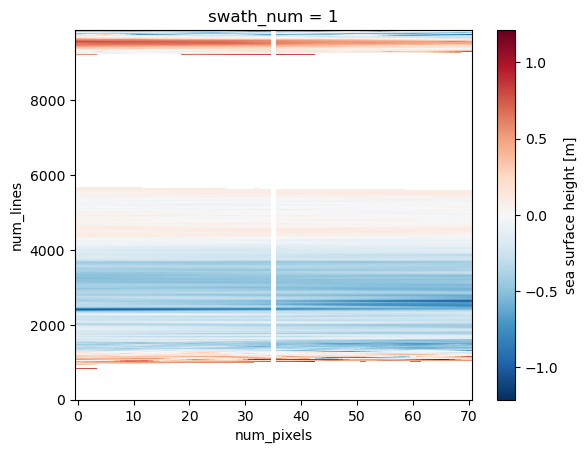

In [100]:
ds.simulated_true_ssh_karin_meanremoved.isel(swath_num=0).plot()

In [3]:
import gc
import os
import re
import glob
import time
import signal
import warnings
import logging
import xarray as xr

# Configure Dask memory settings
dask.config.set({
    "distributed.worker.memory.target": 0.7,
    "distributed.worker.memory.spill": 0.8,
    "distributed.worker.memory.pause": 0.85,
    "distributed.worker.memory.terminate": 0.95,
    "logging.distributed": "error",
})

def create_client():
    """Helper function to create a new Dask client."""
    return Client(
        n_workers=16,
        threads_per_worker=1,
        memory_limit="22GB",
        silence_logs=logging.WARNING,
    )

def reset_client(client):
    """Safely reset Dask client without crashing on teardown timeouts."""
    try:
        client.shutdown()
    except Exception as shutdown_err:
        print(f"Client shutdown warning (safe to ignore): {shutdown_err}")

    try:
        client.close()
    except Exception as close_err:
        print(f"Client close warning (safe to ignore): {close_err}")

    gc.collect()
    new_client = create_client()
    print("Created a fresh Dask client")
    return new_client

class RunTimeoutError(TimeoutError):
    pass

def _timeout_handler(signum, frame):
    raise RunTimeoutError("Run exceeded timeout window without completion")

# macOS supports SIGALRM (this notebook appears to run on macOS)
signal.signal(signal.SIGALRM, _timeout_handler)

# ---------- Tunables ----------
STALL_TIMEOUT_MIN = 20          # hard timeout per region/cycle attempt
STALL_TIMEOUT_SEC = STALL_TIMEOUT_MIN * 60
MAX_RETRIES = 2                 # retries per region/cycle before skip
run_new = False                 # False => skip existing completed outputs
# -----------------------------

USE_TRY_EXCEPT = True
client = create_client()

SIMSWOT_PHASE = "fast_phase" # options: "fast_phase", "science_phase"

problematic_region_cycles = []
problematic_log_path = "problematic_region_cycles.log"

parent_dir = f"/Volumes/Promise Disk/data/simulated_swot/{SIMSWOT_PHASE}"
glob_pattern = f"{parent_dir}/*.nc"
output_dir = f"data/simSWOT/{SIMSWOT_PHASE}/2026-04-19"

file_paths = glob.glob(glob_pattern)
drop_vars = [var for var in xr.open_dataset(file_paths[0]).data_vars if var not in ["simulated_true_ssh_karin", "time"]]
ds_prepadded = xr.open_mfdataset(file_paths, combine='nested', concat_dim='num_lines', parallel=True, decode_times=False, drop_variables=drop_vars)

In [28]:
# Filter ds_prepadded.simulated_true_ssh_karin to only include latlon values from region_dict, iterate over all regions. Use try-except so I can determine which of the 28 swaths actually passes over each region.

for swath in range(ds_prepadded.sizes['swath_num']):
    for region, latlon_values in region_dict.items():
        lat_north = latlon_values["lat_north"]
        lat_south = latlon_values["lat_south"]
        lon_east = latlon_values["lon_east"]
        lon_west = latlon_values["lon_west"]

        # convert negative longitudes to 0..360
        if lon_west < 0:
            lon_west += 360
        if lon_east < 0:
            lon_east += 360

        # print(f"Filtering for region: {region} with lat_north={lat_north}, lat_south={lat_south}, lon_east={lon_east}, lon_west={lon_west}")
        lat_indexer = ((ds_prepadded.isel(swath_num=swath)["latitude"] >= lat_south) & (ds_prepadded.isel(swath_num=swath)["latitude"] <= lat_north)).compute()
        lon_indexer = ((ds_prepadded.isel(swath_num=swath)["longitude"] <= lon_east) & (ds_prepadded.isel(swath_num=swath)["longitude"] >= lon_west)).compute()
        filtered = ds_prepadded.isel(swath_num=swath).where(lat_indexer & lon_indexer, drop=True)

        if filtered.num_lines.size == 0:
            # print(f"No swaths passed over region {region}")
            pass
        else:
            print(f"Swath {swath} passed over region {region} with {filtered.num_pixels} pixels in the filtered area")
            # Add swath index to region_dict for later use, and allow for possibly more than one swath per region by storing in a list
            if "swaths" not in region_dict[region]:
                region_dict[region]["swaths"] = []
            region_dict[region]["swaths"].append(swath)

Swath 3 passed over region capebasin with <xarray.DataArray 'num_pixels' (num_pixels: 71)> Size: 568B
[71 values with dtype=int64]
Dimensions without coordinates: num_pixels pixels in the filtered area
Swath 5 passed over region acc with <xarray.DataArray 'num_pixels' (num_pixels: 71)> Size: 568B
[71 values with dtype=int64]
Dimensions without coordinates: num_pixels pixels in the filtered area
Swath 5 passed over region nwpacific with <xarray.DataArray 'num_pixels' (num_pixels: 71)> Size: 568B
[71 values with dtype=int64]
Dimensions without coordinates: num_pixels pixels in the filtered area
Swath 10 passed over region westatlantic with <xarray.DataArray 'num_pixels' (num_pixels: 71)> Size: 568B
[71 values with dtype=int64]
Dimensions without coordinates: num_pixels pixels in the filtered area
Swath 13 passed over region acc with <xarray.DataArray 'num_pixels' (num_pixels: 71)> Size: 568B
[71 values with dtype=int64]
Dimensions without coordinates: num_pixels pixels in the filtered ar

In [30]:
for region, params in region_dict.items():
    swaths = params.get("swaths", [])
    print(f"Region {region} is covered by swaths: {swaths}")

Region acc is covered by swaths: [5, 13, 19]
Region nwpacific is covered by swaths: [5, 13, 19]
Region capebasin is covered by swaths: [3, 21, 24]
Region newcaledonia is covered by swaths: []
Region nwaustralia is covered by swaths: [26]
Region westatlantic is covered by swaths: [10]
Region labradorsea is covered by swaths: []


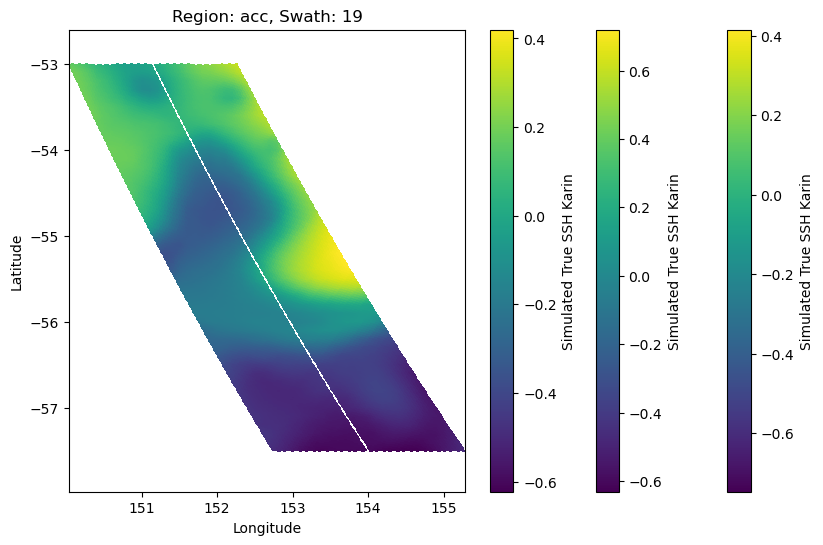

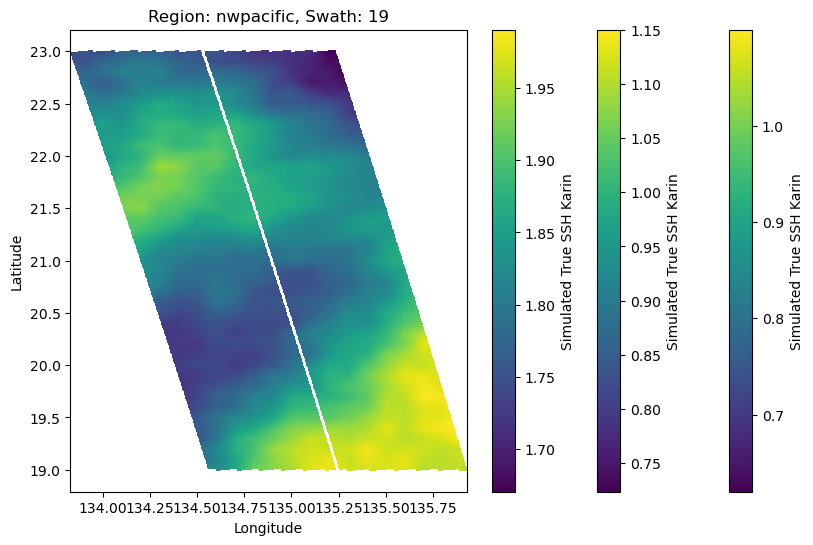

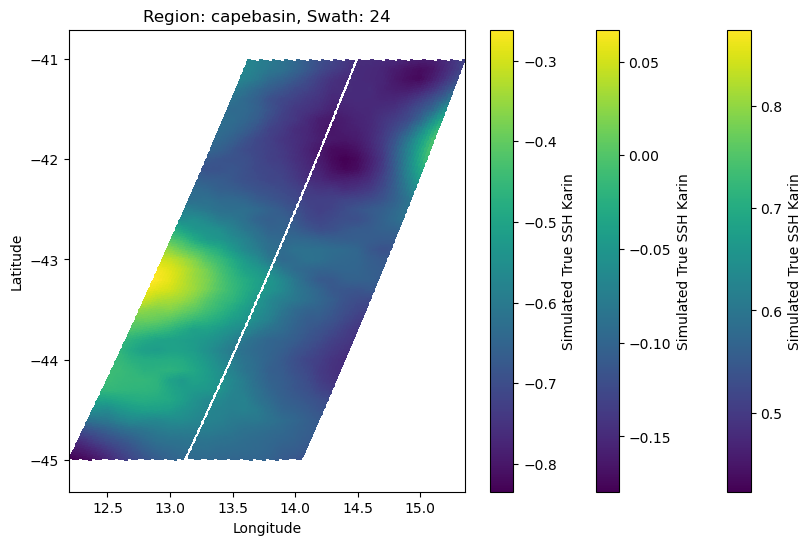

No swaths cover region newcaledonia, skipping plot.


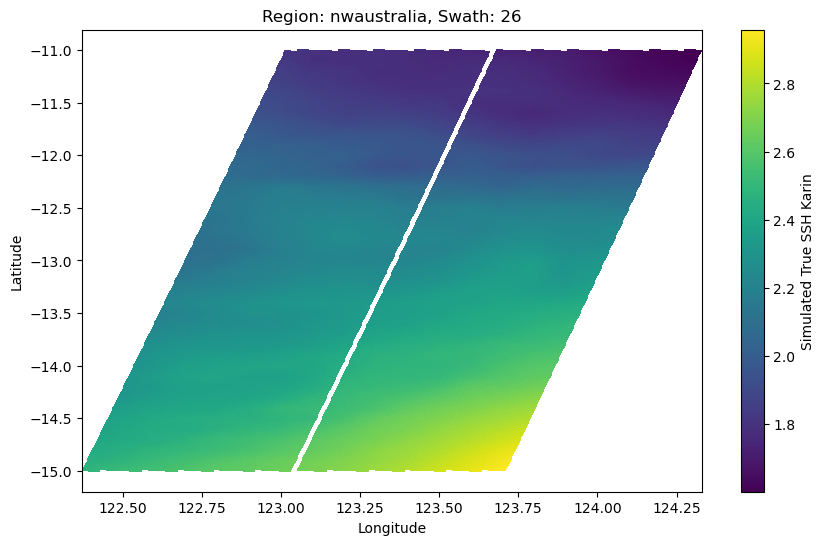

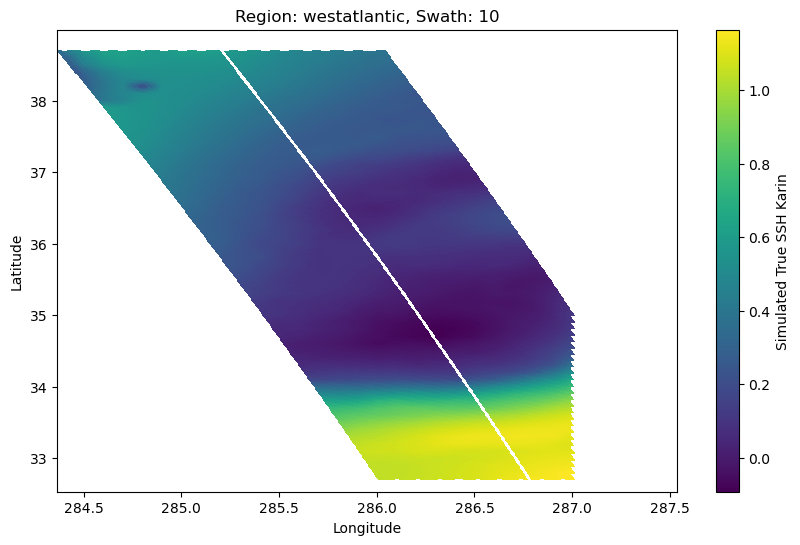

No swaths cover region labradorsea, skipping plot.


In [33]:
# for the swaths that cover each region plot ds.simulated_true_ssh_karin as a pcolormesh with xy as longitude and latitude, to visually confirm the coverage.
import matplotlib.pyplot as plt

for region, params in region_dict.items():
    swaths = params.get("swaths", [])
    if not swaths:
        print(f"No swaths cover region {region}, skipping plot.")
        continue

    plt.figure(figsize=(10, 6))
    for swath in swaths:
        ds_swath = ds_prepadded.isel(swath_num=swath)
        lat_north = params["lat_north"]
        lat_south = params["lat_south"]
        lon_east = params["lon_east"]
        lon_west = params["lon_west"]

        # convert negative longitudes to 0..360
        if lon_west < 0:
            lon_west += 360
        if lon_east < 0:
            lon_east += 360

        lat_indexer = ((ds_swath["latitude"] >= lat_south) & (ds_swath["latitude"] <= lat_north)).compute()
        lon_indexer = ((ds_swath["longitude"] <= lon_east) & (ds_swath["longitude"] >= lon_west)).compute()
        filtered = ds_swath.where(lat_indexer & lon_indexer, drop=True)

        if filtered.num_lines.size == 0:
            print(f"Swath {swath} does not actually cover region {region} after filtering, skipping plot.")
            continue

        plt.pcolormesh(filtered["longitude"], filtered["latitude"], filtered["simulated_true_ssh_karin"], shading='auto')
        plt.colorbar(label='Simulated True SSH Karin')
        plt.title(f"Region: {region}, Swath: {swath}")
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
    plt.show()

In [18]:
ds_test = ds_prepadded.isel(swath_num=5)

lat_indexer = ((ds_test["latitude"] >= lat_south) & (ds_test["latitude"] <= lat_north)).compute()
lon_indexer = ((ds_test["longitude"] <= lon_east) & (ds_test["longitude"] >= lon_west)).compute()
filtered = ds_test.where(lat_indexer & lon_indexer, drop=True)

In [26]:
filtered.num_lines.size

0